# MAB Simulation — ε-Greedy · UCB1 · Thompson Sampling

**Arms**: 5 discount levels applied to the listing's original price: −15%, −10%, 0%, +10%, +15%.  
**Reward**: predicted P(booked | adjusted price) × adjusted price (expected revenue per transaction).  

**Simulation design**:
- Each of the 30 rounds is **independent** — agent state resets at round start.  
- Within each round the agent runs 5 000 transactions, learning which discount maximises revenue.  
- The **within-round learning curve** (cumulative reward vs step, averaged across 30 rounds)  
  shows how fast each strategy converges to the best arm.  
- The **30 per-round totals** provide the sample for statistical testing against the baseline.

## 1. Imports & Configuration

In [48]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, warnings
warnings.filterwarnings('ignore')

BASE_DIR   = os.path.dirname(os.getcwd())
DATA_PATH  = os.path.join(BASE_DIR, 'data',    'processed_data.csv')
MODEL_PATH = os.path.join(BASE_DIR, 'model',   'lgbm_model.pkl')
RESULT_DIR = os.path.join(BASE_DIR, 'results')
os.makedirs(RESULT_DIR, exist_ok=True)

N_ROUNDS       = 30
N_TRANSACTIONS = 50_000
SEED_BASE      = 42       # round r  →  rng seed = SEED_BASE + r

# Arms: discount factors applied to original price_listing
ARM_DISCOUNTS  = np.array([0.70, 0.85, 1.00, 1.15, 1.30])
ARM_LABELS     = ['-30%', '-15%', '0%', '+15%', '+30%']
N_ARMS         = len(ARM_DISCOUNTS)
BASELINE_ARM   = 2    # arm index for 0% discount (no MAB / status quo)

ARM_COLORS = ['#2166AC', '#74ADD1', '#888888', '#F46D43', '#D73027']
AGENT_COLORS = {
    'baseline':           '#888888',
    'epsilon_greedy':     '#E8762B',
    'ucb1':               '#1C8B5A',
    'thompson_sampling':  '#9B59B6',
}

print(f'Arms: {dict(zip(ARM_LABELS, ARM_DISCOUNTS))}')
print(f'N_ROUNDS={N_ROUNDS}  N_TRANSACTIONS={N_TRANSACTIONS:,}')

Arms: {'-30%': np.float64(0.7), '-15%': np.float64(0.85), '0%': np.float64(1.0), '+15%': np.float64(1.15), '+30%': np.float64(1.3)}
N_ROUNDS=30  N_TRANSACTIONS=50,000


## 2. Load Model & Precompute Arm Rewards

In [49]:
saved    = joblib.load(MODEL_PATH)
model    = saved['model']
features = saved['features']

df = pd.read_csv(DATA_PATH, low_memory=False)
df = df.dropna(subset=['price_tier', 'price_listing']).copy()
df['price_tier'] = df['price_tier'].astype(int)
n_rows = len(df)
print(f'Data loaded: {df.shape}  n_rows={n_rows:,}')


def compute_tier(prices):
    """Recompute price_tier after applying a discount (used only for reference, not in arm features)."""
    t = np.zeros(len(prices), dtype=int)
    t[(prices > 100) & (prices <= 300)] = 1
    t[(prices > 300) & (prices <= 600)] = 2
    t[prices > 600] = 3
    return t


# Precompute reward for every (arm, row) pair.
# price_tier is kept at the listing's ORIGINAL tier — it reflects the property category,
# not the temporarily adjusted transaction price.
print('\nPre-computing rewards for each discount arm...')
arm_rewards = np.zeros((N_ARMS, n_rows))
arm_probs   = np.zeros((N_ARMS, n_rows))

for a, discount in enumerate(ARM_DISCOUNTS):
    df_mod = df[features].copy()
    new_prices = df['price_listing'].values * discount
    if 'price_listing' in features:
        df_mod['price_listing'] = new_prices
    # price_tier intentionally NOT updated — original listing category is preserved
    probs = model.predict_proba(df_mod)[:, 1]
    arm_rewards[a] = probs * new_prices
    arm_probs[a]   = probs
    print(f'  Arm {a} ({ARM_LABELS[a]:>4s}, x{discount})  '
          f'mean_price={new_prices.mean():.0f}  '
          f'mean_P={probs.mean():.4f}  '
          f'mean_reward={arm_rewards[a].mean():.2f}')

print(f'\narm_rewards shape: {arm_rewards.shape}')
print('Best arm by mean reward:',
      ARM_LABELS[int(np.argmax(arm_rewards.mean(axis=1)))])

# ── Per-tier × per-arm stats (P(booked), price, reward) — saved for 08 visualisation ──
N_TIERS = 4
TIER_LABELS_VIZ = {0: 'Budget (≤$100)', 1: 'Standard ($101-300)',
                   2: 'Premium ($301-600)', 3: 'Luxury (>$600)'}
tier_vals = df['price_tier'].values
tier_arm_rows = []
for a, discount in enumerate(ARM_DISCOUNTS):
    adj_prices = df['price_listing'].values * discount
    for t in range(N_TIERS):
        mask = (tier_vals == t)
        tier_arm_rows.append({
            'arm': a, 'arm_label': ARM_LABELS[a],
            'tier': t, 'tier_label': TIER_LABELS_VIZ[t],
            'mean_prob':      float(arm_probs[a, mask].mean()),
            'mean_adj_price': float(adj_prices[mask].mean()),
            'mean_reward':    float(arm_rewards[a, mask].mean()),
            'n_listings':     int(mask.sum()),
        })
tier_arm_df = pd.DataFrame(tier_arm_rows)
tier_arm_df.to_csv(os.path.join(RESULT_DIR, 'tier_arm_stats.csv'), index=False)
print('\nSaved tier_arm_stats.csv')
print(tier_arm_df.pivot(index='tier_label', columns='arm_label', values='mean_prob').round(4))

# ── Stratified tier pools — matching 05_baseline.ipynb ───────────────
tier_pool_indices = {t: np.where(tier_vals == t)[0] for t in range(N_TIERS)}
tier_props = {t: len(v) / n_rows for t, v in tier_pool_indices.items()}
tier_ns    = {t: int(np.floor(tier_props[t] * N_TRANSACTIONS)) for t in range(N_TIERS)}
tier_ns[max(tier_props, key=tier_props.get)] += N_TRANSACTIONS - sum(tier_ns.values())
print('\nTier sample counts per round:', {t: tier_ns[t] for t in range(N_TIERS)})


def sample_round_indices(round_idx):
    """
    Stratified-by-tier sampling matching 05_baseline.ipynb exactly.
    Each tier uses a fresh np.random.RandomState(SEED_BASE + round_idx),
    mirroring pandas sample(random_state=seed) used in 05.
    """
    seed = SEED_BASE + round_idx
    idx_list = []
    for t in range(N_TIERS):
        rs   = np.random.RandomState(seed)
        pool = tier_pool_indices[t]
        idx_list.extend(pool[rs.choice(len(pool), size=tier_ns[t], replace=True)])
    return np.array(idx_list)

Data loaded: (953380, 19)  n_rows=953,380

Pre-computing rewards for each discount arm...
  Arm 0 (-30%, x0.7)  mean_price=191  mean_P=0.2650  mean_reward=49.61
  Arm 1 (-15%, x0.85)  mean_price=231  mean_P=0.2564  mean_reward=58.69
  Arm 2 (  0%, x1.0)  mean_price=272  mean_P=0.2541  mean_reward=68.53
  Arm 3 (+15%, x1.15)  mean_price=313  mean_P=0.2517  mean_reward=78.18
  Arm 4 (+30%, x1.3)  mean_price=354  mean_P=0.2490  mean_reward=86.98

arm_rewards shape: (5, 953380)
Best arm by mean reward: +30%

Saved tier_arm_stats.csv
arm_label              +15%    +30%    -15%    -30%      0%
tier_label                                                 
Budget (≤$100)       0.2127  0.2164  0.2182  0.2305  0.2138
Luxury (>$600)       0.2492  0.2380  0.2478  0.2595  0.2445
Premium ($301-600)   0.2439  0.2352  0.2384  0.2284  0.2447
Standard ($101-300)  0.2851  0.2835  0.2973  0.3144  0.2910

Tier sample counts per round: {0: 13878, 1: 19411, 2: 12404, 3: 4307}


## 3. MAB Agent Classes

In [50]:
class EpsilonGreedy:
    """Epsilon-greedy with exponential decay. reset() re-initialises for each round."""
    def __init__(self, n_arms=N_ARMS, epsilon=0.20, decay=0.999, eps_min=0.02):
        self.n_arms, self._eps0, self.decay, self.eps_min = n_arms, epsilon, decay, eps_min
        self.reset()

    def reset(self):
        self.epsilon = self._eps0
        self.Q = np.zeros(self.n_arms)
        self.N = np.zeros(self.n_arms)

    def select_arm(self):
        if np.random.rand() < self.epsilon:
            return int(np.random.randint(self.n_arms))
        return int(np.argmax(self.Q))

    def update(self, arm, reward):
        self.N[arm] += 1
        self.Q[arm] += (reward - self.Q[arm]) / self.N[arm]
        self.epsilon  = max(self.eps_min, self.epsilon * self.decay)

    def arm_values(self): return self.Q.copy()
    def name(self):       return 'epsilon_greedy'


class UCB1:
    """UCB1 (Auer et al. 2002).  Selects argmax Q(a) + c*sqrt(ln t / N(a))."""
    def __init__(self, n_arms=N_ARMS, c=2.0):
        self.n_arms, self.c = n_arms, c
        self.reset()

    def reset(self):
        self.Q = np.zeros(self.n_arms)
        self.N = np.zeros(self.n_arms)
        self.t = 0

    def select_arm(self):
        unvisited = np.where(self.N == 0)[0]
        if len(unvisited):
            return int(unvisited[0])
        return int(np.argmax(self.Q + self.c * np.sqrt(np.log(self.t) / self.N)))

    def update(self, arm, reward):
        self.t += 1;  self.N[arm] += 1
        self.Q[arm] += (reward - self.Q[arm]) / self.N[arm]

    def arm_values(self): return self.Q.copy()
    def name(self):       return 'ucb1'


class ThompsonSampling:
    """
    Gaussian Thompson Sampling.
    Samples theta_a ~ N(Q_a, (sigma / sqrt(N_a))^2) and picks argmax.
    sigma is set relative to expected reward scale (~100 SGD).
    """
    def __init__(self, n_arms=N_ARMS, sigma=50.0):
        self.n_arms, self.sigma = n_arms, sigma
        self.reset()

    def reset(self):
        self.Q = np.zeros(self.n_arms)
        self.N = np.zeros(self.n_arms)

    def select_arm(self):
        std     = self.sigma / np.sqrt(np.maximum(self.N, 1))
        samples = np.random.normal(self.Q, std)
        return int(np.argmax(samples))

    def update(self, arm, reward):
        self.N[arm] += 1
        self.Q[arm] += (reward - self.Q[arm]) / self.N[arm]

    def arm_values(self): return self.Q.copy()
    def name(self):       return 'thompson_sampling'

## 4. Simulation Loop

In [51]:
def run_simulation(agent, arm_rewards,
                   n_rounds=N_ROUNDS, n_transactions=N_TRANSACTIONS):
    """
    Run MAB simulation over n_rounds, each round independent (agent resets).
    Row sampling uses sample_round_indices() — stratified by price tier,
    matching 05_baseline.ipynb so all strategies see the same data.

    Returns
    -------
    results_df        : DataFrame, one row per round (total_reward, arm counts, Q values)
    within_cumulative : ndarray (n_rounds, n_transactions) — step-wise cumulative reward
    arm_history       : ndarray (n_rounds, n_transactions, dtype=int8) — arm at each step
    """
    n_arms  = arm_rewards.shape[0]
    records = []
    within_cumulative = np.zeros((n_rounds, n_transactions))
    arm_history       = np.zeros((n_rounds, n_transactions), dtype=np.int8)

    for r in range(n_rounds):
        agent.reset()
        round_indices = sample_round_indices(r)      # stratified, same as 05 baseline
        arm_counts    = np.zeros(n_arms, dtype=int)
        arm_totals    = np.zeros(n_arms)
        cumulative    = 0.0

        for step in range(n_transactions):
            arm    = agent.select_arm()
            idx    = int(round_indices[step])
            reward = float(arm_rewards[arm, idx])
            agent.update(arm, reward)
            arm_counts[arm]  += 1
            arm_totals[arm]  += reward
            cumulative       += reward
            within_cumulative[r, step] = cumulative
            arm_history[r, step]       = arm

        q_vals = agent.arm_values()
        rec    = {'round': r + 1, 'total_reward': cumulative}
        for a in range(n_arms):
            rec[f'n_arm_{a}']      = int(arm_counts[a])
            rec[f'reward_arm_{a}'] = float(arm_totals[a])
            rec[f'q_arm_{a}']      = float(q_vals[a])
        records.append(rec)

        print(f'Round {r+1:2d}/30  reward={cumulative:>9,.0f}  '
              f'counts={arm_counts.tolist()}  '
              f'Q={np.round(q_vals, 1).tolist()}')

    return pd.DataFrame(records), within_cumulative, arm_history

In [52]:
all_results    = {}   # name -> results_df
all_within     = {}   # name -> within_cumulative (n_rounds, n_transactions)
all_arm_hist   = {}   # name -> arm_history

# ── Load 05's baseline (stratified sampling, 0% discount) ─────────────
baseline_csv = pd.read_csv(os.path.join(RESULT_DIR, 'baseline_results.csv'))
print(f'Baseline loaded from 05  |  mean reward/round: {baseline_csv["total_reward"].mean():,.0f}')

# Re-derive step-wise cumulative from the same stratified indices + arm 2 rewards
print('Computing baseline within-round curve from stratified indices...')
baseline_wc = np.zeros((N_ROUNDS, N_TRANSACTIONS))
for r in range(N_ROUNDS):
    round_indices = sample_round_indices(r)
    baseline_wc[r] = np.cumsum(arm_rewards[BASELINE_ARM, round_indices])

all_results['baseline']  = baseline_csv[['round', 'total_reward']]
all_within['baseline']   = baseline_wc
all_arm_hist['baseline'] = np.full((N_ROUNDS, N_TRANSACTIONS), BASELINE_ARM, dtype=np.int8)

# ── Run MAB agents ─────────────────────────────────────────────────────
agent_defs = [
    ('epsilon_greedy',    EpsilonGreedy(),    SEED_BASE + 10),
    ('ucb1',              UCB1(),             SEED_BASE + 20),
    ('thompson_sampling', ThompsonSampling(), SEED_BASE + 30),
]
for name, agent, seed in agent_defs:
    print(f'\n=== {name} ===')
    np.random.seed(seed)
    res, wc, ah = run_simulation(agent, arm_rewards)
    all_results[name]  = res
    all_within[name]   = wc
    all_arm_hist[name] = ah

print('\nAll simulations complete.')

Baseline loaded from 05  |  mean reward/round: 3,434,626
Computing baseline within-round curve from stratified indices...

=== epsilon_greedy ===
Round  1/30  reward=4,281,477  counts=[246, 224, 321, 11473, 37736]  Q=[37.7, 51.1, 51.3, 18.1, 107.0]
Round  2/30  reward=4,316,132  counts=[237, 259, 222, 6127, 43155]  Q=[45.1, 46.6, 47.7, 18.5, 96.6]
Round  3/30  reward=4,358,210  counts=[227, 444, 234, 217, 48878]  Q=[42.3, 34.4, 45.8, 59.0, 88.2]
Round  4/30  reward=4,309,120  counts=[242, 227, 265, 577, 48689]  Q=[52.1, 59.3, 51.8, 35.2, 87.3]
Round  5/30  reward=4,294,070  counts=[218, 335, 235, 226, 48986]  Q=[59.9, 44.4, 65.4, 56.6, 86.5]
Round  6/30  reward=4,386,874  counts=[239, 255, 243, 218, 49045]  Q=[42.8, 49.5, 67.6, 47.9, 88.4]
Round  7/30  reward=4,313,157  counts=[238, 304, 233, 269, 48956]  Q=[46.8, 55.6, 62.8, 57.1, 86.9]
Round  8/30  reward=4,320,821  counts=[211, 240, 224, 278, 49047]  Q=[47.8, 59.3, 43.9, 64.4, 87.0]
Round  9/30  reward=4,314,702  counts=[270, 233, 2

## 5. Results Summary

In [53]:
b_mean = all_results['baseline']['total_reward'].mean()
print(f'{"Strategy":<22} {"Mean/round":>12} {"Std":>9} {"vs Baseline":>13}')
print('-' * 60)
for name, df_r in all_results.items():
    mean = df_r['total_reward'].mean()
    std  = df_r['total_reward'].std()
    diff = f'{(mean - b_mean) / b_mean * 100:+.2f}%' if name != 'baseline' else '—'
    print(f'{name:<22} {mean:>12,.0f} {std:>9,.0f} {diff:>13}')

Strategy                 Mean/round       Std   vs Baseline
------------------------------------------------------------
baseline                  3,434,626    30,911             —
epsilon_greedy            4,272,154   147,438       +24.38%
ucb1                      3,629,642   693,308        +5.68%
thompson_sampling         4,348,252    37,534       +26.60%


## 6. Visualisation

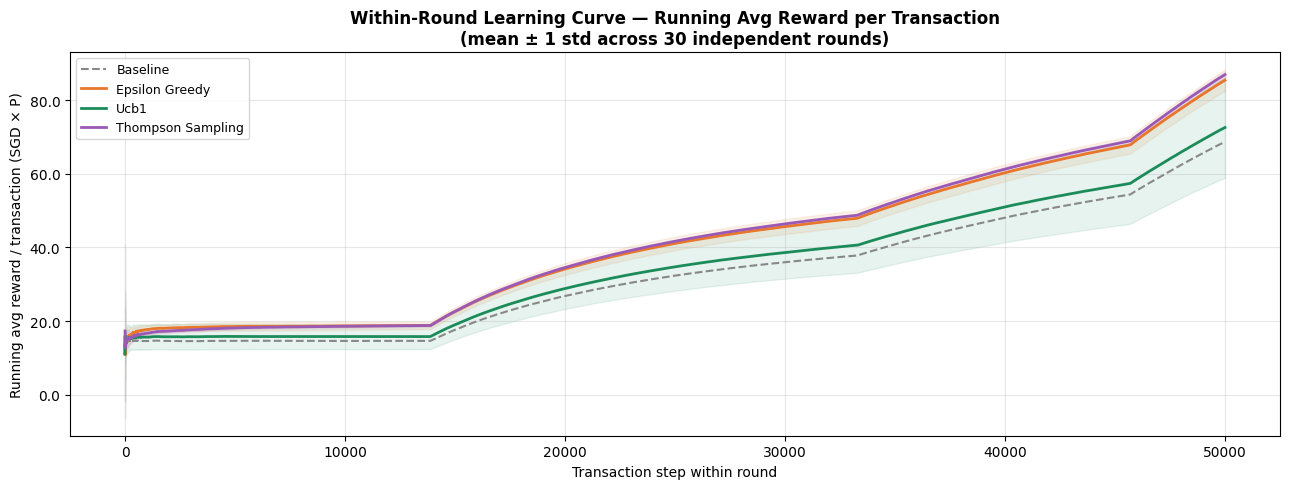

Upward slope = agent learning to pick higher-reward arms over the 5 000 steps.


In [54]:
# ── Within-round learning curve (main plot) ────────────────────────────
# Shows: given agent starts from zero, how fast does it converge to the best arm?
# Y-axis: running average reward per transaction  (cumulative / step)
# Each line = mean across 30 rounds; shaded band = ±1 std

steps = np.arange(1, N_TRANSACTIONS + 1)

fig, ax = plt.subplots(figsize=(13, 5))

for name, wc in all_within.items():
    # Convert cumulative reward to running average per transaction
    running_avg = wc / steps[np.newaxis, :]     # shape (n_rounds, n_transactions)
    mean_curve  = running_avg.mean(axis=0)
    std_curve   = running_avg.std(axis=0)
    color = AGENT_COLORS[name]
    ls    = '--' if name == 'baseline' else '-'
    lw    = 1.5  if name == 'baseline' else 2.0
    ax.plot(steps, mean_curve, color=color, linestyle=ls, linewidth=lw,
            label=name.replace('_', ' ').title())
    if name != 'baseline':
        ax.fill_between(steps, mean_curve - std_curve, mean_curve + std_curve,
                        color=color, alpha=0.10)

ax.set_title('Within-Round Learning Curve — Running Avg Reward per Transaction\n'
             '(mean ± 1 std across 30 independent rounds)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Transaction step within round')
ax.set_ylabel('Running avg reward / transaction (SGD × P)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'mab_within_round_learning.png'), dpi=120)
plt.show()
print('Upward slope = agent learning to pick higher-reward arms over the 5 000 steps.')

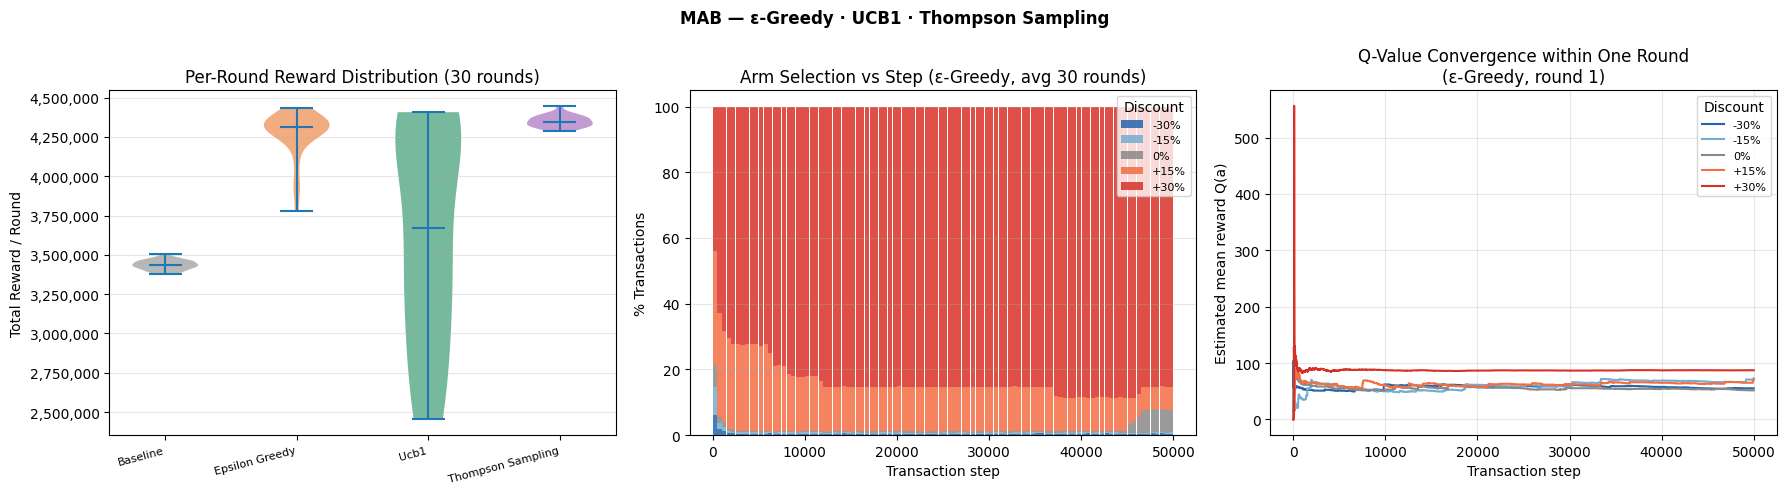

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MAB — ε-Greedy · UCB1 · Thompson Sampling', fontsize=12, fontweight='bold')

# ── (1) Per-round total reward — 30 rounds distribution ───────────────
ax = axes[0]
names   = list(all_results.keys())
data    = [all_results[n]['total_reward'].values for n in names]
labels  = [n.replace('_', ' ').title() for n in names]
colors  = [AGENT_COLORS[n] for n in names]
vp = ax.violinplot(data, positions=range(len(names)), showmedians=True)
for body, color in zip(vp['bodies'], colors):
    body.set_facecolor(color);  body.set_alpha(0.6)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
ax.set_title('Per-Round Reward Distribution (30 rounds)')
ax.set_ylabel('Total Reward / Round')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(alpha=0.3, axis='y')

# ── (2) Arm selection evolution within a round (avg across 30 rounds) ──
ax = axes[1]
# Use ε-Greedy as representative example; bin into 500-step windows
BIN = 500
n_bins  = N_TRANSACTIONS // BIN
bin_mids = (np.arange(n_bins) + 0.5) * BIN
ah_eg   = all_arm_hist['epsilon_greedy']    # (n_rounds, n_transactions)
bottom  = np.zeros(n_bins)
for a in range(N_ARMS):
    prop = np.array([
        (ah_eg[:, b*BIN:(b+1)*BIN] == a).mean()
        for b in range(n_bins)
    ])
    ax.bar(bin_mids, prop * 100, bottom=bottom, width=BIN * 0.9,
           color=ARM_COLORS[a], label=ARM_LABELS[a], alpha=0.85)
    bottom += prop * 100
ax.set_title('Arm Selection vs Step (ε-Greedy, avg 30 rounds)')
ax.set_xlabel('Transaction step')
ax.set_ylabel('% Transactions')
ax.legend(fontsize=8, title='Discount')
ax.grid(alpha=0.3, axis='y')

# ── (3) Q-value convergence within a round (ε-Greedy) ────────────────
# Re-run one round with Q recorded every step for illustration
ax = axes[2]
agent_demo = EpsilonGreedy()
agent_demo.reset()
rng_demo   = np.random.default_rng(SEED_BASE)
q_trace    = np.zeros((N_TRANSACTIONS, N_ARMS))
for step in range(N_TRANSACTIONS):
    arm    = agent_demo.select_arm()
    idx    = int(rng_demo.integers(n_rows))
    reward = float(arm_rewards[arm, idx])
    agent_demo.update(arm, reward)
    q_trace[step] = agent_demo.arm_values()
for a in range(N_ARMS):
    ax.plot(np.arange(1, N_TRANSACTIONS + 1), q_trace[:, a],
            color=ARM_COLORS[a], linewidth=1.5, label=ARM_LABELS[a])
ax.set_title('Q-Value Convergence within One Round\n(ε-Greedy, round 1)')
ax.set_xlabel('Transaction step')
ax.set_ylabel('Estimated mean reward Q(a)')
ax.legend(fontsize=8, title='Discount')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'mab_analysis.png'), dpi=120)
plt.show()

## 7. Save Results

In [56]:
# Save baseline_within_round for use by 07_linucb.ipynb
np.save(os.path.join(RESULT_DIR, 'baseline_within_round.npy'), baseline_wc)
print(f'Saved within: {os.path.join(RESULT_DIR, "baseline_within_round.npy")}')

# Save MAB agent results only (baseline_results.csv is owned by 05_baseline.ipynb)
for name, df_r in all_results.items():
    if name == 'baseline':
        continue
    path = os.path.join(RESULT_DIR, f'{name}_results.csv')
    df_r.to_csv(path, index=False)
    print(f'Saved results:  {path}')

for name, wc in all_within.items():
    if name == 'baseline':
        continue
    path = os.path.join(RESULT_DIR, f'{name}_within_round.npy')
    np.save(path, wc)
    print(f'Saved within:   {path}')

# Save arm history for tier-level analysis in 08_comparison.ipynb
for name, ah in all_arm_hist.items():
    if name == 'baseline':
        continue
    path = os.path.join(RESULT_DIR, f'{name}_arm_history.npy')
    np.save(path, ah)
    print(f'Saved arm_hist: {path}')

Saved within: d:\School\msba\作业\5113\group\sg\results\baseline_within_round.npy
Saved results:  d:\School\msba\作业\5113\group\sg\results\epsilon_greedy_results.csv
Saved results:  d:\School\msba\作业\5113\group\sg\results\ucb1_results.csv
Saved results:  d:\School\msba\作业\5113\group\sg\results\thompson_sampling_results.csv
Saved within:   d:\School\msba\作业\5113\group\sg\results\epsilon_greedy_within_round.npy
Saved within:   d:\School\msba\作业\5113\group\sg\results\ucb1_within_round.npy
Saved within:   d:\School\msba\作业\5113\group\sg\results\thompson_sampling_within_round.npy
Saved arm_hist: d:\School\msba\作业\5113\group\sg\results\epsilon_greedy_arm_history.npy
Saved arm_hist: d:\School\msba\作业\5113\group\sg\results\ucb1_arm_history.npy
Saved arm_hist: d:\School\msba\作业\5113\group\sg\results\thompson_sampling_arm_history.npy
